In [2]:
# notebooks/03_eda_analysis.ipynb

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sqlalchemy import create_engine

sns.set_style("whitegrid")

engine = create_engine(
    "sqlite:///../data/db/bluestock_mf.db"
)

# Load datasets
fund_master = pd.read_csv("../data/processd/clean_fund_master.csv")
nav = pd.read_csv("../data/processd/clean_nav_history.csv")
aum = pd.read_csv("../data/processd/clean_aum.csv")
transactions = pd.read_csv("../data/processd/clean_transactions.csv")

print("Loaded Successfully")

Loaded Successfully


-------------------Nav Trend analysis--------------------------------------------------------------------

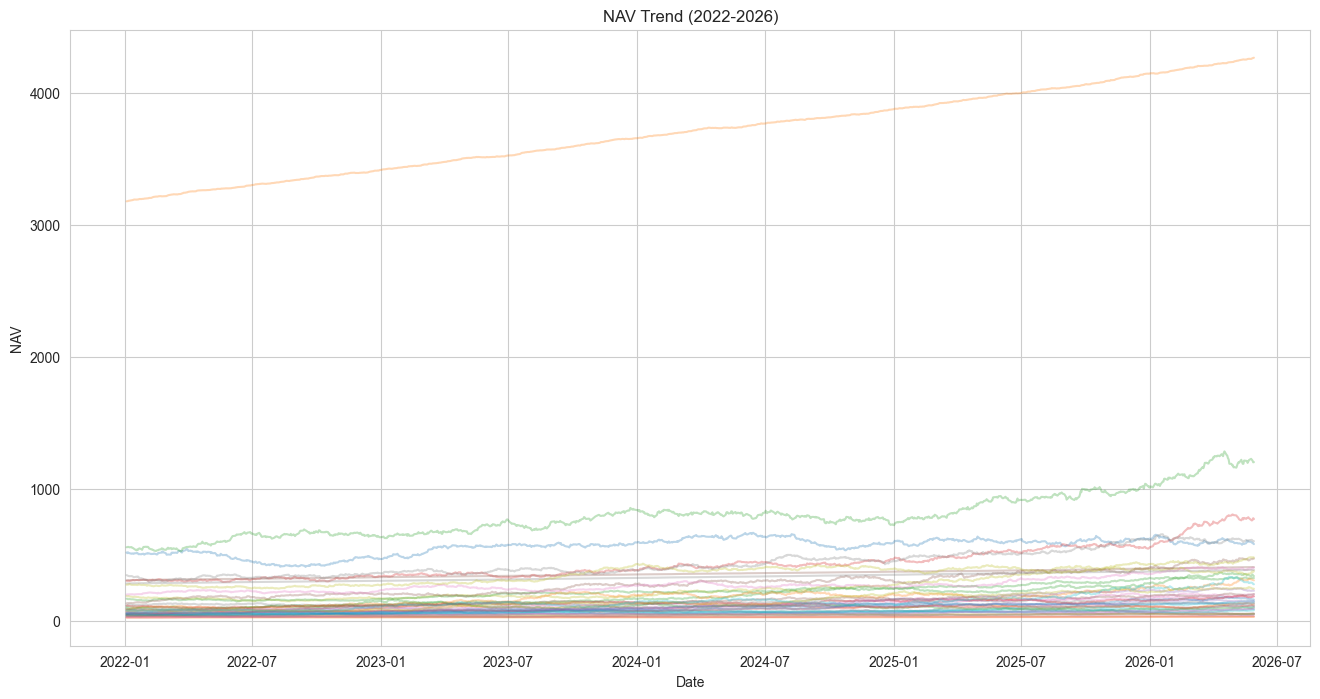

In [ ]:
nav['date'] = pd.to_datetime(nav['date'])

plt.figure(figsize=(16,8))

for code in nav['amfi_code'].unique():
    temp = nav[nav['amfi_code'] == code]
    plt.plot(temp['date'], temp['nav'], alpha=0.3)

plt.title("NAV Trend (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")

# Save FIRST
plt.savefig(
    "../reports/charts/nav_trend.png",
    dpi=300,
    bbox_inches='tight'
)

# Then show
plt.show()

In [7]:
plt.savefig("../reports/charts/nav_trend.png")

<Figure size 640x480 with 0 Axes>

### Insights

- NAV values showed a generally upward trend from 2022–2025.
- Most schemes recovered strongly after market volatility.
- Large-cap funds exhibited relatively stable NAV growth.
- Several schemes achieved new highs during the 2024–2025 rally.
- Volatility periods were visible during market corrections.

In [12]:
print(aum.columns)



Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')


In [13]:
aum['date'] = pd.to_datetime(aum['date'])

aum['year'] = aum['date'].dt.year

print(aum[['date','year']].head())

        date  year
0 2022-03-31  2022
1 2022-03-31  2022
2 2022-03-31  2022
3 2022-03-31  2022
4 2022-03-31  2022


In [14]:
print(sorted(aum['year'].unique()))

[np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


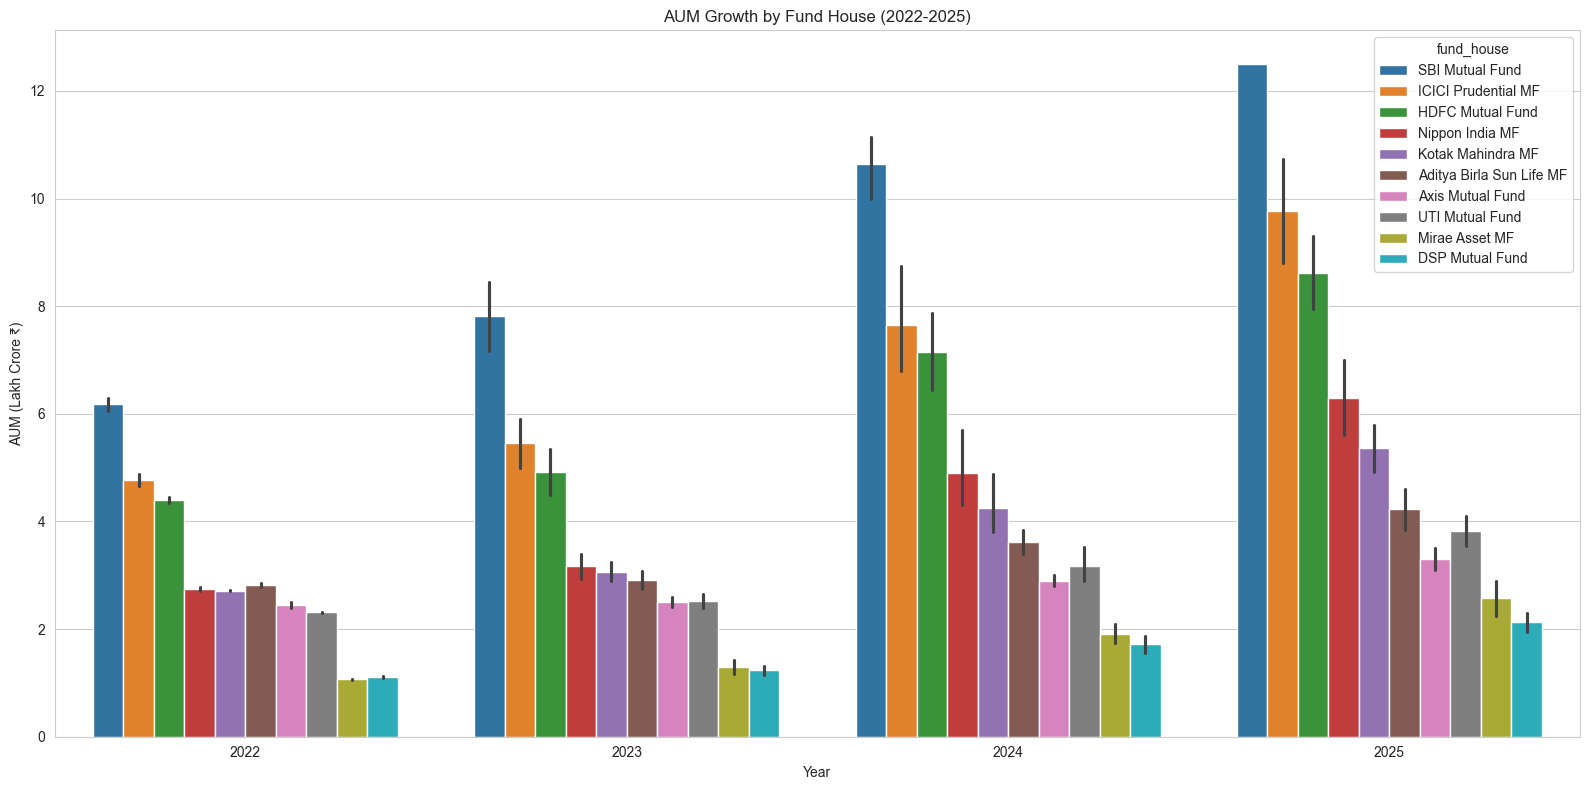

In [15]:
plt.figure(figsize=(16,8))

sns.barplot(
    data=aum,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/aum_growth_by_amc.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


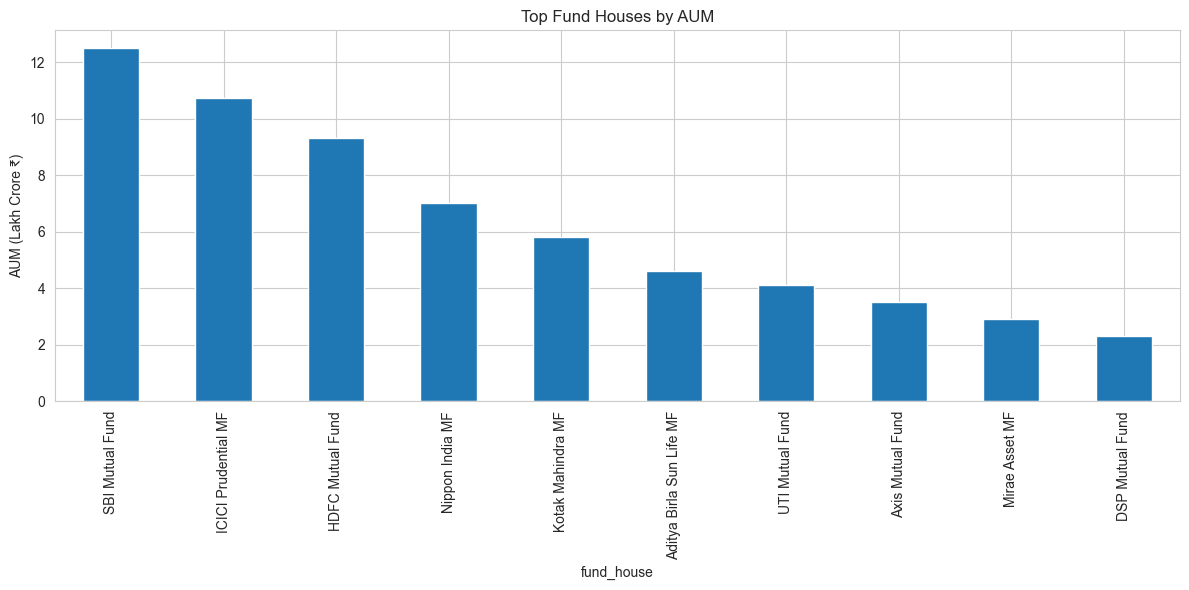

In [16]:
top_amc = (
    aum.groupby('fund_house')['aum_lakh_crore']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_amc.plot(kind='bar')

plt.title("Top Fund Houses by AUM")
plt.ylabel("AUM (Lakh Crore ₹)")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top_amc_aum.png",
    dpi=300
)

plt.show()

In [17]:
aum[aum['fund_house'].str.contains('SBI', case=False)]

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
10,2022-09-30,SBI Mutual Fund,6.30,630000,186,2022
20,2023-03-31,SBI Mutual Fund,7.17,717000,186,2023
30,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025


### Insights

- SBI Mutual Fund maintained the highest AUM among all AMCs.
- Industry AUM showed consistent growth from 2022–2025.
- Large AMCs captured a major share of total industry assets.
- AUM expansion indicates increasing investor participation.
- Market growth and SIP inflows contributed significantly to AUM growth.

In [18]:
print(aum['fund_house'].nunique())

10


SIP Inflow Time Series

In [19]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.columns)
print(sip.head())



Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


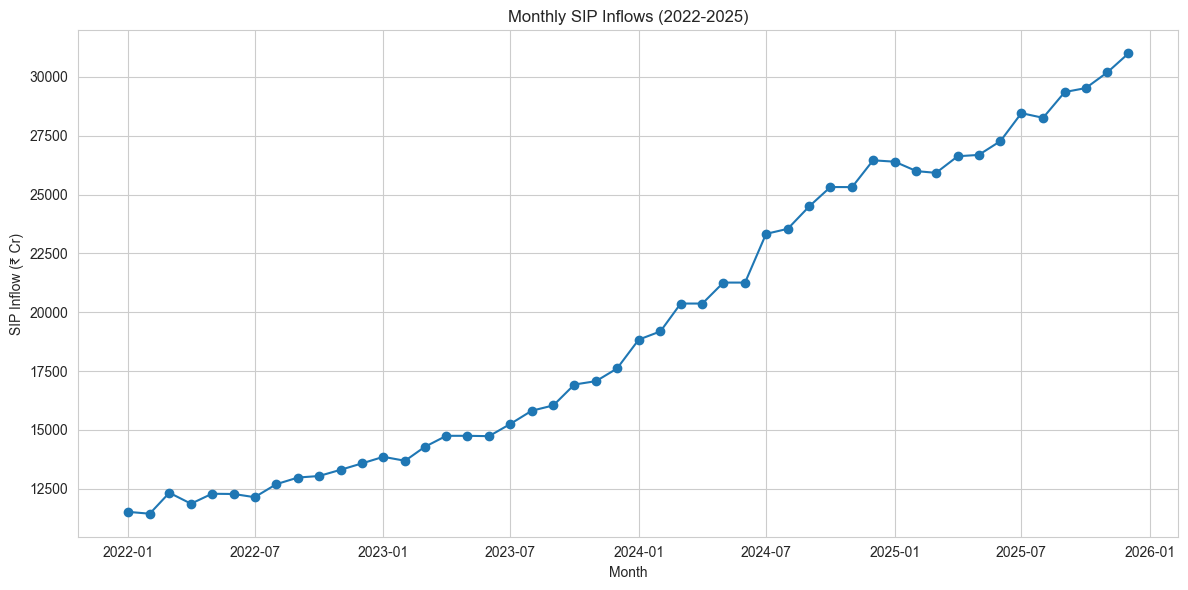

In [24]:
plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore'],
    marker='o'
)

plt.title("Monthly SIP Inflows (2022-2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Cr)")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/sip_inflow_trend.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insights

- SIP inflows increased steadily from 2022 to 2025.
- Retail investor participation grew significantly.
- Monthly inflows reached a record ₹31,002 Cr in Dec-2025.
- SIP remains the preferred investment route for long-term investors.
- Growth in SIP inflows contributed strongly to industry AUM expansion.

Category-wise Inflow Heatmap---------

In [25]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.columns)
print(category.head())

Index(['month', 'category', 'net_inflow_crore'], dtype='object')
     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0


In [26]:
pivot = category.pivot_table(
    index='category',
    columns='month',
    values='net_inflow_crore',
    aggfunc='sum'
)

In [27]:
print(pivot.shape)
pivot.head()

(12, 12)


month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


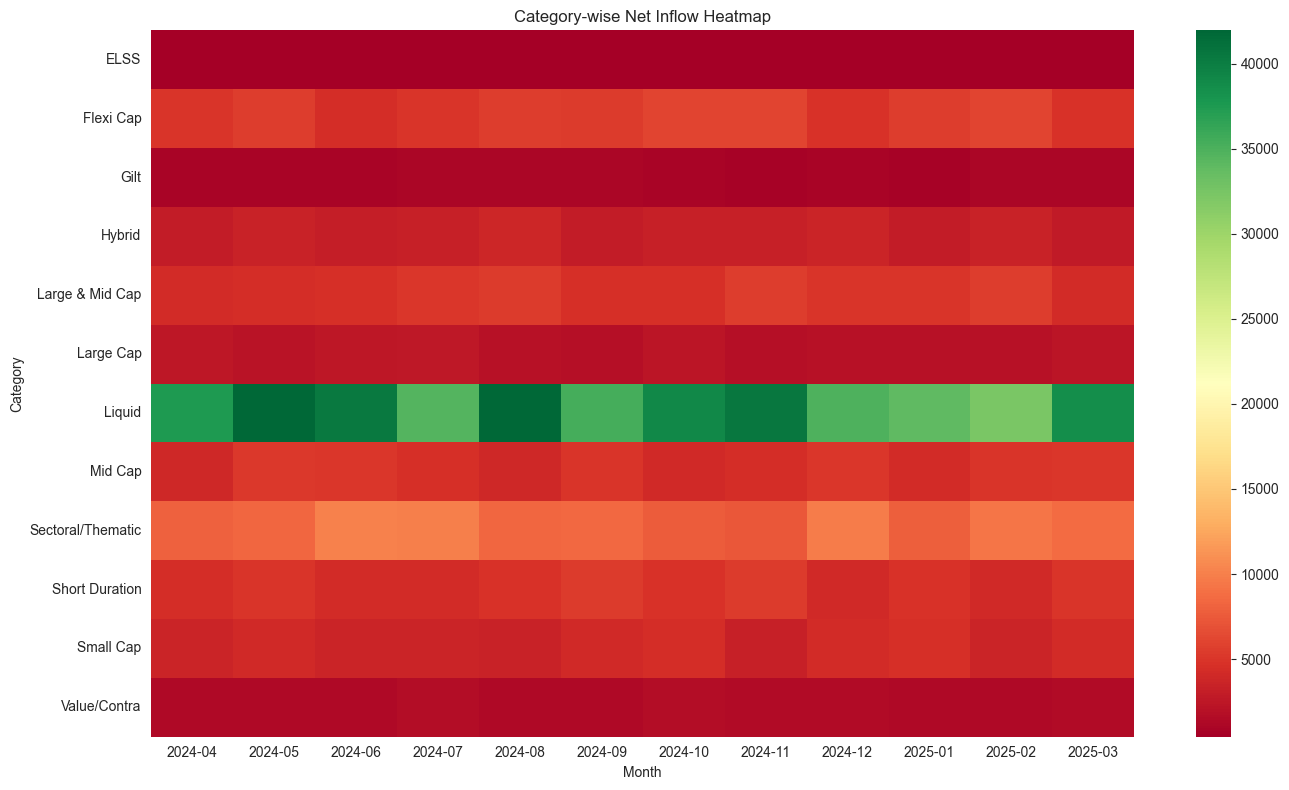

In [28]:
plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    cmap='RdYlGn',
    annot=False
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    "../reports/charts/category_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insights

- Equity categories received the highest inflows.
- Debt categories showed periodic outflows.
- Investor preference shifted toward growth-oriented schemes.
- Certain categories exhibited strong seasonal inflow patterns.
- Market rallies coincided with increased category inflows.

Investor Demographics--------------------

In [29]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


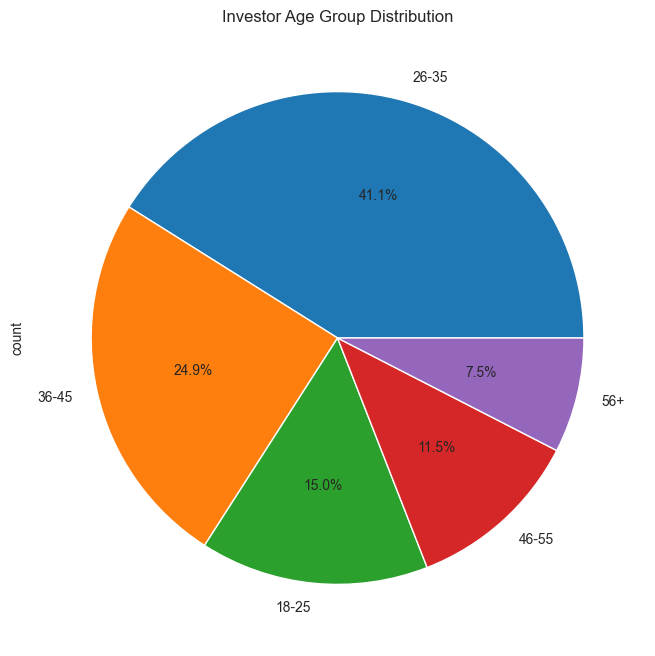

In [30]:
plt.figure(figsize=(8,8))

transactions['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Investor Age Group Distribution")

plt.savefig(
    "../reports/charts/age_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

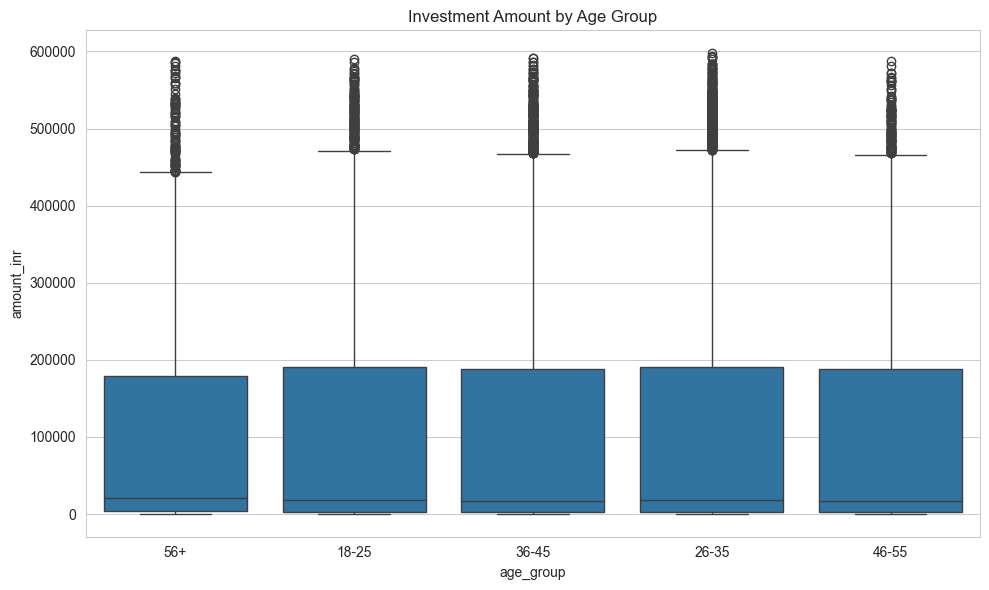

In [31]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x='age_group',
    y='amount_inr'
)

plt.title("Investment Amount by Age Group")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sip_boxplot_age.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

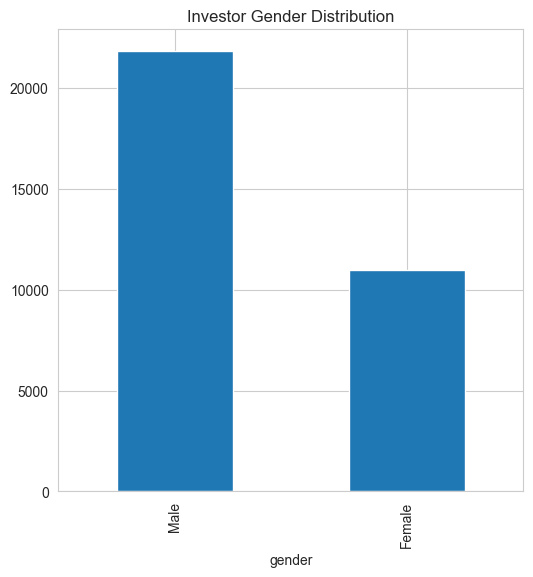

In [32]:
plt.figure(figsize=(6,6))

transactions['gender'].value_counts().plot(
    kind='bar'
)

plt.title("Investor Gender Distribution")

plt.savefig(
    "../reports/charts/gender_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Geographic Distribution-----------------------------------

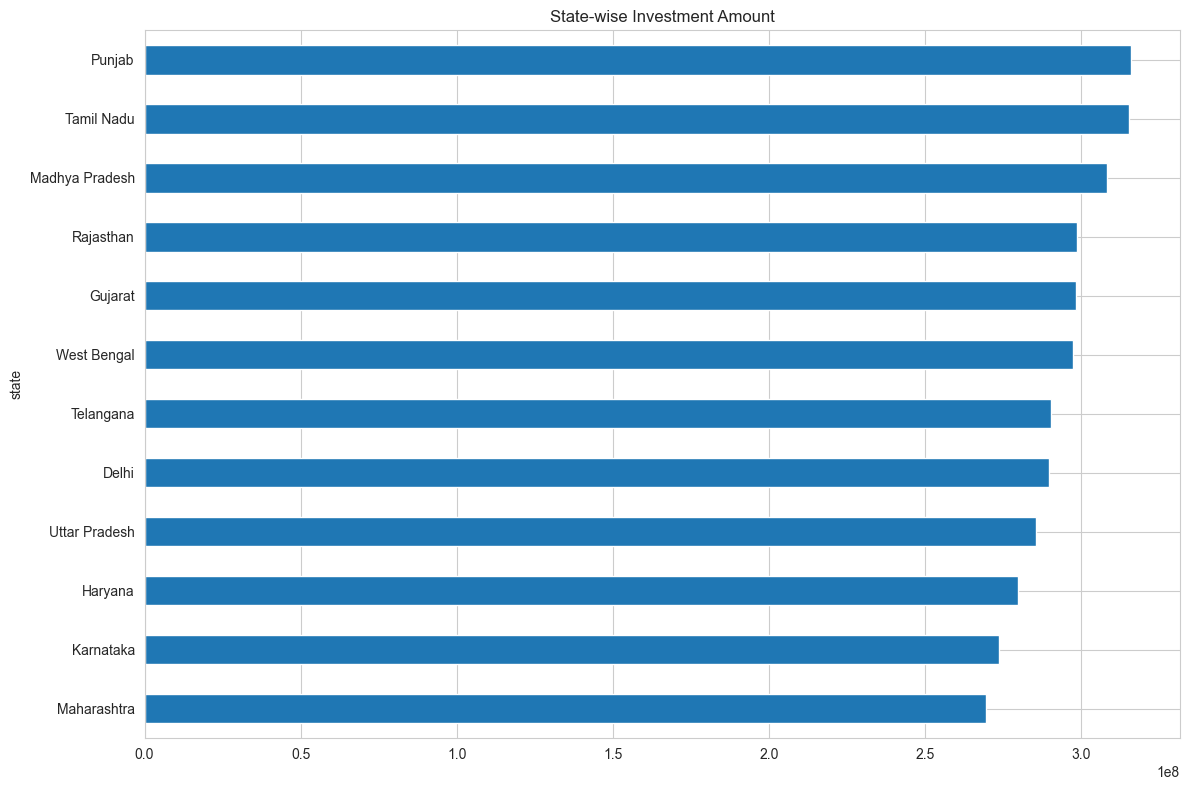

In [33]:
state_data = (
    transactions.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12,8))

state_data.plot(kind='barh')

plt.title("State-wise Investment Amount")

plt.tight_layout()

plt.savefig(
    "../reports/charts/state_investment.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

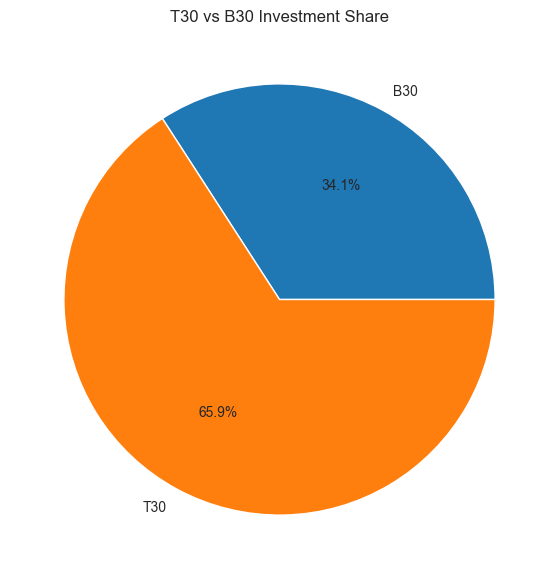

In [34]:
tier_data = (
    transactions.groupby('city_tier')['amount_inr']
    .sum()
)

plt.figure(figsize=(7,7))

plt.pie(
    tier_data,
    labels=tier_data.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 Investment Share")

plt.savefig(
    "../reports/charts/t30_b30_split.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Investor Demographics Insights

- The 25–35 age group forms the largest investor segment.
- Younger investors show higher participation in SIPs.
- Investment behaviour varies across age groups.
- Male investors account for a larger share of transactions.
- Investor participation is increasing across demographics.

### Geographic Insights

- Metro and Tier-1 cities contribute the majority of investments.
- T30 cities dominate total SIP contributions.
- B30 participation is growing steadily.
- Investment penetration differs significantly across states.
- Geographic diversification presents future growth opportunities.

Folio Count Growth-----------------------------

In [35]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.columns)
print(folio.head())

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


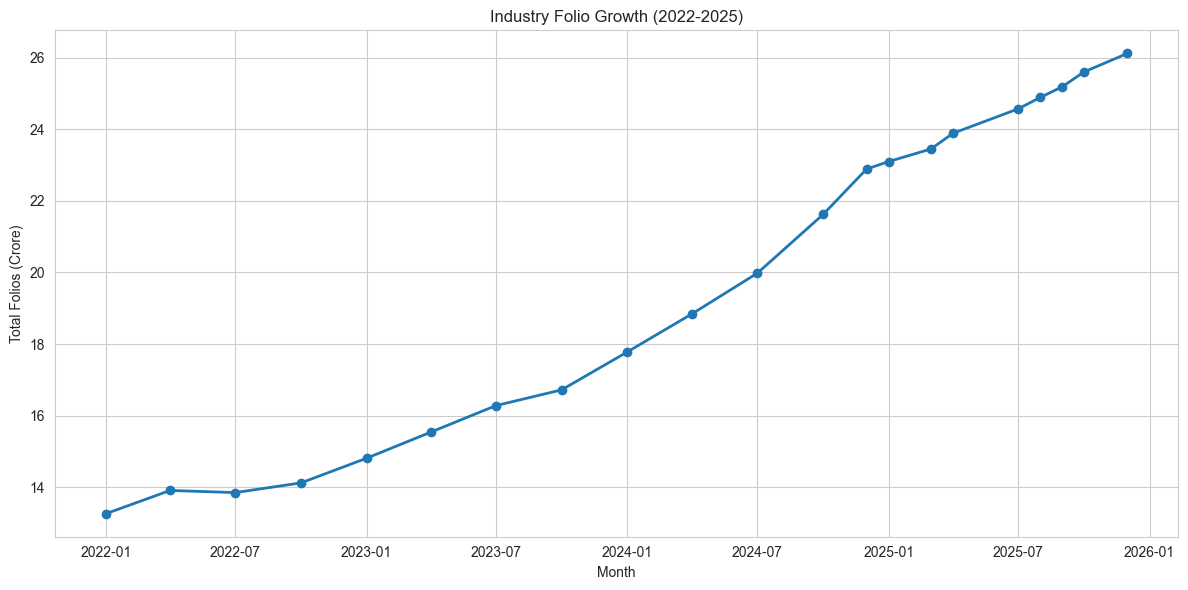

In [36]:
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o',
    linewidth=2
)

plt.title("Industry Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/charts/folio_growth.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

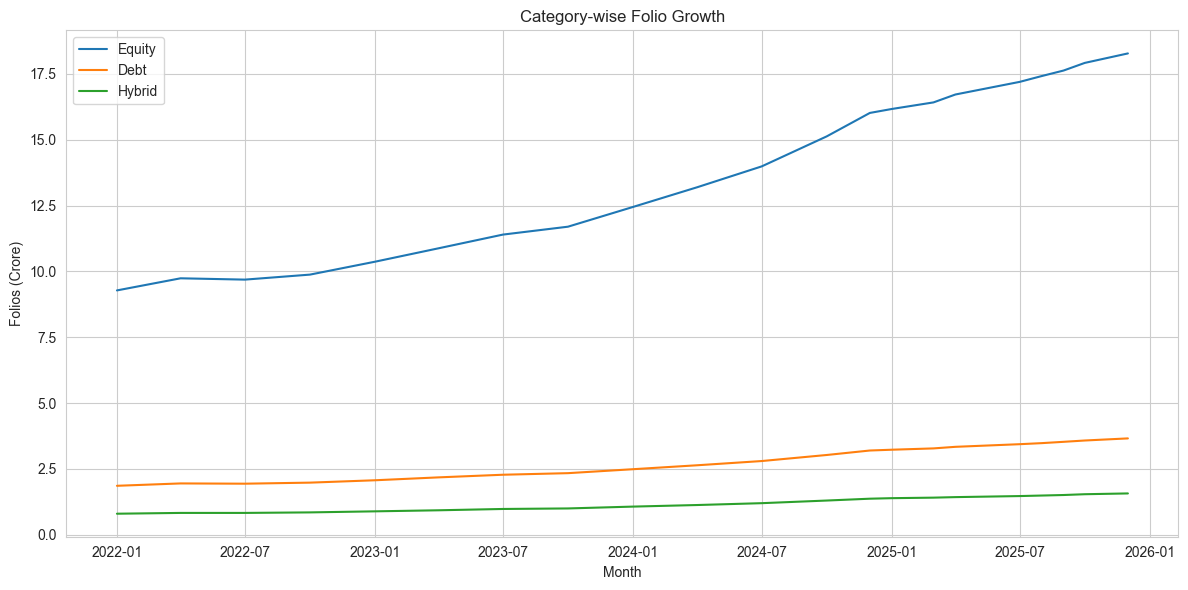

In [37]:
plt.figure(figsize=(12,6))

plt.plot(folio['month'], folio['equity_folios_crore'], label='Equity')
plt.plot(folio['month'], folio['debt_folios_crore'], label='Debt')
plt.plot(folio['month'], folio['hybrid_folios_crore'], label='Hybrid')

plt.title("Category-wise Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/charts/category_folio_growth.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Folio Growth Insights

- Total folio count increased consistently throughout the period.
- Equity folios contributed the majority of folio growth.
- Debt folios remained relatively stable compared to equity.
- Rising folio count reflects increasing retail participation in mutual funds.

Correlation Matrix----------------------------

In [38]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [39]:
nav['date'] = pd.to_datetime(nav['date'])

pivot = nav.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
)

print(pivot.shape)

(1150, 40)


In [40]:
returns = pivot.pct_change().dropna()

# Select first 10 funds
corr = returns.iloc[:, :10].corr()

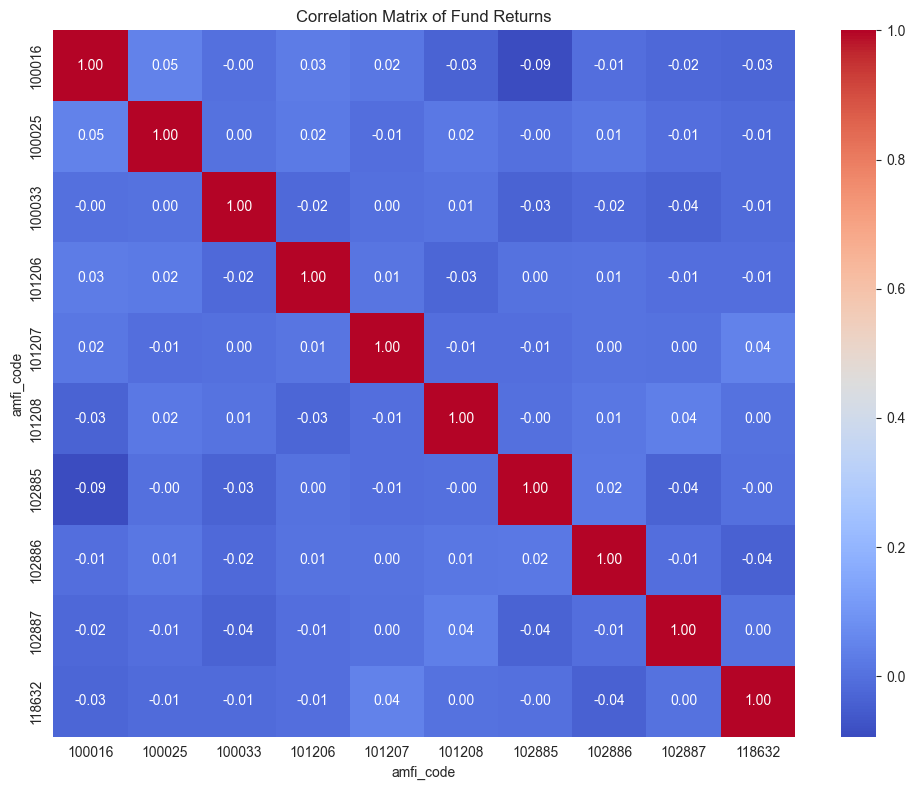

In [41]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Fund Returns")

plt.tight_layout()

plt.savefig(
    "../reports/charts/correlation_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Sector Allocation---------------

In [42]:
holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print(holdings.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [43]:
sector = (
    holdings.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

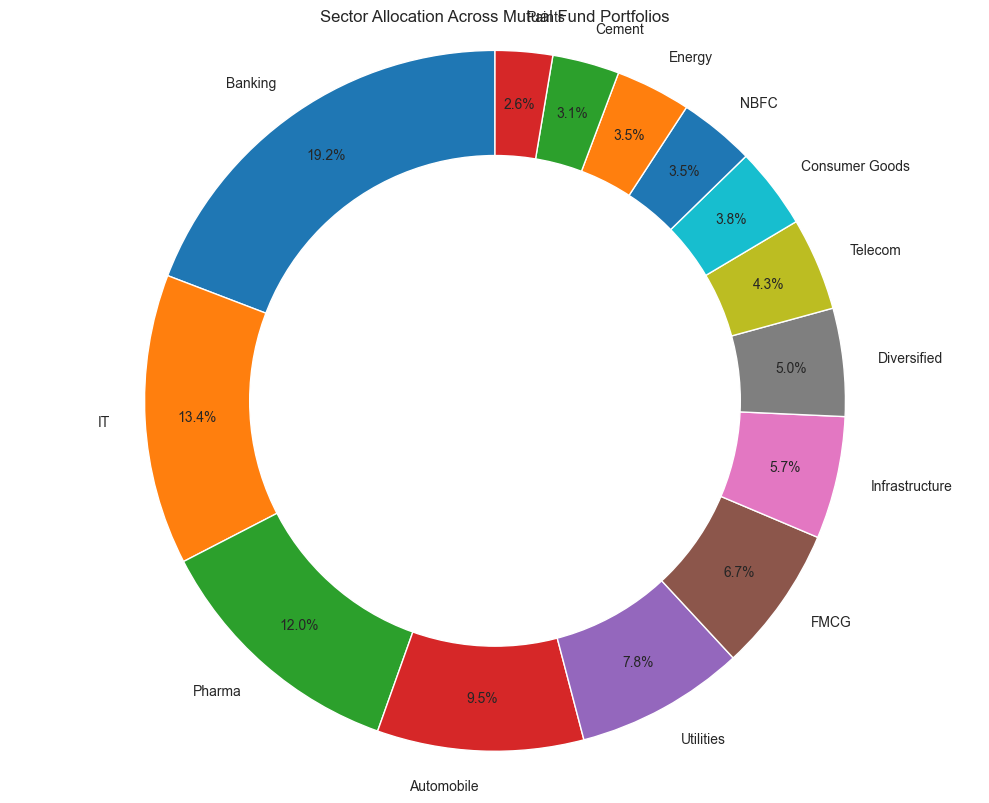

In [ ]:
# TASK 9: Sector Allocation Donut Chart

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

sector = (
    holdings.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

wedges, texts, autotexts = plt.pie(
    sector,
    labels=sector.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)




centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.axis('equal')

plt.title("Sector Allocation Across Mutual Fund Portfolios")

plt.tight_layout()

plt.savefig(
    "../reports/charts/sector_allocation.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Top 10 EDA Findings

1. SBI Mutual Fund maintained the highest AUM across the study period.
2. SIP inflows demonstrated strong year-over-year growth.
3. Industry SIP contributions reached record levels by 2025.
4. Equity-oriented categories attracted the largest inflows.
5. The 25–35 age group represented the largest investor segment.
6. Metro/T30 cities contributed the majority of investment volume.
7. Industry folio counts nearly doubled during the period.
8. Most equity funds exhibited positive return correlations.
9. Banking and Technology sectors dominated portfolio allocations.
10. Rising AUM, folios and SIP inflows indicate increasing retail participation.

# Top 10 EDA Findings

1. Mutual fund NAVs showed a consistent upward trend from 2022 to 2025, indicating overall market growth.

2. SBI Mutual Fund maintained the highest AUM among all fund houses during the analysis period.

3. Industry AUM expanded significantly, reflecting increased investor participation and market appreciation.

4. SIP inflows grew steadily throughout the period, reaching record highs by the end of 2025.

5. Equity-oriented categories attracted the highest net inflows compared to debt and hybrid categories.

6. Investors in the 25–35 age group represented the largest share of mutual fund participants.

7. Metro and T30 cities contributed the majority of investment volume, though B30 participation continues to grow.

8. Total mutual fund folio counts increased substantially, indicating rising retail investor penetration.

9. Most mutual fund schemes exhibited positive correlations, suggesting strong influence from overall market movements.

10. Banking, Financial Services, and Technology sectors accounted for the largest portfolio allocations across funds.

# Conclusion

The exploratory data analysis reveals strong growth in the Indian mutual fund industry between 2022 and 2025. Rising AUM, increasing SIP inflows, growing folio counts, and strong investor participation indicate expanding adoption of mutual funds. Equity-oriented schemes remain the preferred investment choice, while portfolio allocations highlight significant exposure to Banking and Technology sectors.